In [ ]:
! pip install pyportfolioopt quantstats

importing libraries

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models, expected_returns
from datetime import datetime, timedelta
import quantstats as qs

In [ ]:
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'JPM', 'JNJ', 'TSLA', 'NVDA', 'PG',
           'UNH', 'V', 'HD', 'DIS', 'PEP', 'KO', 'MA', 'MRK', 'XOM', 'CVX']
end_date = '2024-12-31'
start_date = '2010-01-01'

df1 = yf.download(tickers, start=start_date, end=end_date)["Close"]
returns = df1.pct_change().dropna()
returns.columns = tickers
returns.index = pd.to_datetime(returns.index)
returns_monthly = returns.resample('ME').mean()  # Use 'ME' instead of deprecated 'M'
returns_monthly.index = returns_monthly.index.to_period('M')
df = returns_monthly.copy()
df

/tmp/ipython-input-7-3612739008.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df1 = yf.download(tickers, start=start_date, end=end_date)["Close"]
[*********************100%***********************]  20 of 20 completed


,AAPL,MSFT,GOOGL,AMZN,META,JPM,JNJ,TSLA,NVDA,PG,UNH,V,HD,DIS,PEP,KO,MA,MRK,XOM,CVX
Date,,,,,,,,,,,,,,,,,,,,
2012-05,0.010970,-0.000432,-0.000105,0.005361,-0.004012,0.006742,-0.000605,-0.001044,0.001164,0.003871,-0.029636,-0.000786,-0.000272,0.003773,0.000499,-0.002424,0.009373,0.004127,0.002959,-0.004369
2012-06,0.000600,0.003454,0.003487,0.002892,0.000032,0.003562,0.003803,0.003841,0.002535,0.002860,0.002870,0.005578,0.002385,0.005483,0.001953,-0.000749,0.003335,0.002561,0.003533,0.004140
2012-07,0.002249,0.001266,0.001850,0.000694,0.004252,-0.000653,0.001184,0.000979,0.001608,0.000870,-0.016216,0.002810,-0.001668,-0.000744,0.001405,0.002957,-0.005657,-0.006235,0.002172,0.000748
2012-08,0.003964,0.002751,0.001382,0.000322,0.003493,0.003933,-0.000734,0.001412,-0.003319,-0.001349,-0.007332,-0.001091,0.002271,0.001651,-0.000163,0.001779,0.002216,0.002694,-0.000165,0.000527
2012-09,0.000252,0.001358,0.002058,0.002960,0.005143,0.003307,0.001153,0.004659,0.001142,0.003495,0.010448,0.002985,-0.001781,-0.002476,-0.000803,0.001685,0.002153,0.001342,0.002464,0.002480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08,0.001549,-0.001760,-0.003066,-0.001482,-0.002096,0.000418,0.002636,0.002603,0.003783,0.001963,0.004446,0.002129,0.000023,0.001726,0.000094,0.003016,-0.003004,0.001161,0.001950,0.000198
2024-09,0.000970,0.002290,-0.000138,0.003151,0.000946,0.004800,-0.001129,-0.003072,-0.000047,0.001110,0.004839,-0.001709,0.001618,0.001490,-0.000403,0.000531,0.010627,-0.000253,-0.000138,-0.000176
2024-10,-0.001259,0.000119,0.000499,0.000080,0.001433,-0.001200,-0.000563,0.002590,-0.004112,0.000606,-0.000245,-0.004456,-0.002366,0.004189,-0.000995,-0.001781,-0.000707,-0.001331,0.002354,-0.000094


In [ ]:
ff_factors = pd.read_csv("F-F_Research_Data_Factors.csv", index_col=0)
ff_factors.index = pd.to_datetime(ff_factors.index, format="%Y%m").to_period('M')
common_index = df.index.intersection(ff_factors.index)
df = df.loc[common_index]
ff_factors = ff_factors.loc[common_index]

In [ ]:
ff_df = pd.concat([ff_factors, df], axis=1).dropna()

excess_returns = ff_df[tickers].subtract(ff_df['RF'], axis=0)

In [ ]:
factors = ff_factors[['Mkt-RF', 'SMB', 'HML']] / 100
rf = ff_factors['RF']
betas = {}

for ticker in tickers:
    y = excess_returns[ticker] / 100
    X = sm.add_constant(factors)
    model = sm.OLS(y, X).fit()
    betas[ticker] = model.params

betas_df = pd.DataFrame(betas).T
betas_df

,const,Mkt-RF,SMB,HML
AAPL,-0.000997,0.000379,0.004482,0.002935
MSFT,-0.000997,0.000459,0.004502,0.002765
GOOGL,-0.001001,0.000309,0.004584,0.003620
AMZN,-0.001003,0.000434,0.004562,0.003240
META,-0.000997,0.000352,0.004404,0.003065
JPM,-0.000997,0.000278,0.004611,0.003200
JNJ,-0.000999,0.000134,0.004436,0.003276
TSLA,-0.000998,0.000359,0.004643,0.003598
NVDA,-0.001000,0.000139,0.004277,0.003312
PG,-0.000997,0.000341,0.004433,0.003223


In [ ]:
import cvxpy as cp

w = cp.Variable(len(tickers))
constraints = [
    cp.sum(w) == 1,
    betas_df['HML'].values @ w == 0
]
objective = cp.Minimize(cp.sum_squares(w))
prob = cp.Problem(objective, constraints)
prob.solve()
hml_neutral_weights = w.value
print("HML-Neutral Portfolio Weights:", dict(zip(tickers, np.round(hml_neutral_weights, 4))))

HML-Neutral Portfolio Weights: {'AAPL': np.float64(0.5754), 'MSFT': np.float64(0.9566), 'GOOGL': np.float64(-0.9602), 'AMZN': np.float64(-0.1092), 'META': np.float64(0.283), 'JPM': np.float64(-0.0194), 'JNJ': np.float64(-0.1889), 'TSLA': np.float64(-0.9102), 'NVDA': np.float64(-0.2698), 'PG': np.float64(-0.0712), 'UNH': np.float64(0.6421), 'V': np.float64(-0.0801), 'HD': np.float64(0.392), 'DIS': np.float64(0.9733), 'PEP': np.float64(-0.0856), 'KO': np.float64(-0.1173), 'MA': np.float64(1.0861), 'MRK': np.float64(-0.067), 'XOM': np.float64(0.0735), 'CVX': np.float64(-1.103)}


In [ ]:
mu = expected_returns.mean_historical_return(df1)
S = risk_models.sample_cov(df1)

ef = EfficientFrontier(mu, S)
ef.max_sharpe()
cleaned_trad_weights = ef.clean_weights()
print("Traditional MVO Weights:", cleaned_trad_weights)

Traditional MVO Weights: OrderedDict([('AAPL', 0.17788), ('AMZN', 0.03952), ('CVX', 0.0), ('DIS', 0.0), ('GOOGL', 0.0), ('HD', 0.19547), ('JNJ', 0.0), ('JPM', 0.0), ('KO', 0.0), ('MA', 0.0), ('META', 0.0), ('MRK', 0.0), ('MSFT', 0.0), ('NVDA', 0.17681), ('PEP', 0.0), ('PG', 0.05827), ('TSLA', 0.09814), ('UNH', 0.25391), ('V', 0.0), ('XOM', 0.0)])


In [ ]:
factor_premia = ff_factors[['Mkt-RF', 'SMB', 'HML']].mean()
betas = betas_df[['Mkt-RF', 'SMB', 'HML']]
mu_factor = (betas * factor_premia.values).sum(axis=1) + rf.mean()
ef_factor = EfficientFrontier(mu_factor, S)
ef_1=ef_factor
factor_weights = ef_factor.max_sharpe()
cleaned_factor_weights = ef_factor.clean_weights()
print("Factor-Adjusted MVO Weights:", cleaned_factor_weights)

Factor-Adjusted MVO Weights: OrderedDict([('AAPL', 0.00511), ('MSFT', 0.03623), ('GOOGL', 0.0), ('AMZN', 0.01138), ('META', 0.00971), ('JPM', 0.01377), ('JNJ', 0.25953), ('TSLA', 0.0), ('NVDA', 0.18852), ('PG', 0.0), ('UNH', 0.01422), ('V', 0.09696), ('HD', 0.0), ('DIS', 0.0), ('PEP', 0.09486), ('KO', 0.21064), ('MA', 0.00186), ('MRK', 0.0), ('XOM', 0.0), ('CVX', 0.05722)])


In [ ]:
trad_mvo_returns = df.dot(pd.Series(cleaned_trad_weights))
fact_adj_returns = df.dot(pd.Series(cleaned_factor_weights))
trad_mvo_returns = pd.Series(trad_mvo_returns.values, index=trad_mvo_returns.index.to_timestamp(), name="Optimized")
fact_adj_returns = pd.Series(fact_adj_returns.values, index=fact_adj_returns.index.to_timestamp(), name="Benchmark")

a = qs.reports.metrics(trad_mvo_returns, mode='monthly',display=False)
b = qs.reports.metrics(fact_adj_returns, mode='monthly',display=False)
compare = pd.concat([a, b], axis=1)
compare.columns = ['Traditonal MVO Strategy','Factor-Based Strategy']
compare

,Traditonal MVO Strategy,Factor-Based Strategy
Start Period,2012-05-01,2012-05-01
End Period,2024-07-01,2024-07-01
Risk-Free Rate,0,0
Time in Market,1.0,1.0
Cumulative Return,0.14,0.08
CAGR﹪,0.01,0
Sharpe,5.72,4.84
Prob. Sharpe Ratio,1.0,1.0
Sortino,10.12,8.27
Sortino/√2,7.16,5.84


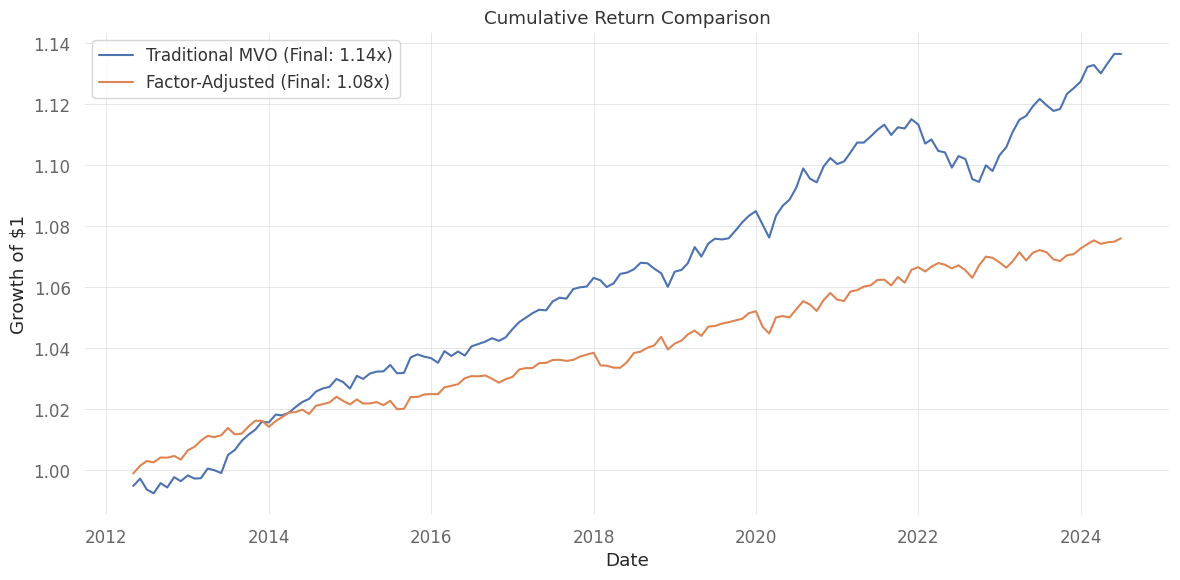


Factor portfolio outperformed by -5.3%


In [ ]:
# Ensuring proper datetime indices
if isinstance(fact_adj_returns.index, pd.PeriodIndex):
    fact_adj_returns.index = fact_adj_returns.index.to_timestamp()
if isinstance(trad_mvo_returns.index, pd.PeriodIndex):
    trad_mvo_returns.index = trad_mvo_returns.index.to_timestamp()

# Plotting
plt.figure(figsize=(12,6))
cum_trad = (1 + trad_mvo_returns).cumprod()
cum_factor = (1 + fact_adj_returns).cumprod()

plt.plot(cum_trad, label=f'Traditional MVO (Final: {cum_trad.iloc[-1]:.2f}x)')
plt.plot(cum_factor, label=f'Factor-Adjusted (Final: {cum_factor.iloc[-1]:.2f}x)')

plt.title("Cumulative Return Comparison")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

outperformance = (cum_factor.iloc[-1] - cum_trad.iloc[-1])/cum_trad.iloc[-1]*100
print(f"\nFactor portfolio outperformed by {outperformance:.1f}%")

different strategies portfolio allocation

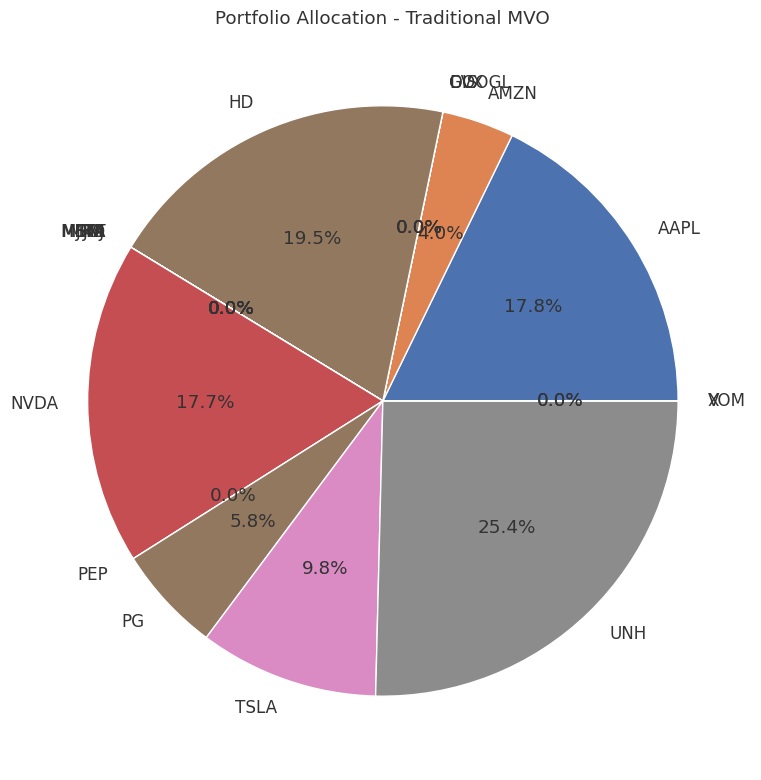

In [ ]:
# Traditional MVO Allocation Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(cleaned_trad_weights.values(), labels=cleaned_trad_weights.keys(), autopct='%1.1f%%')
plt.title("Portfolio Allocation - Traditional MVO")
plt.tight_layout()
plt.show()


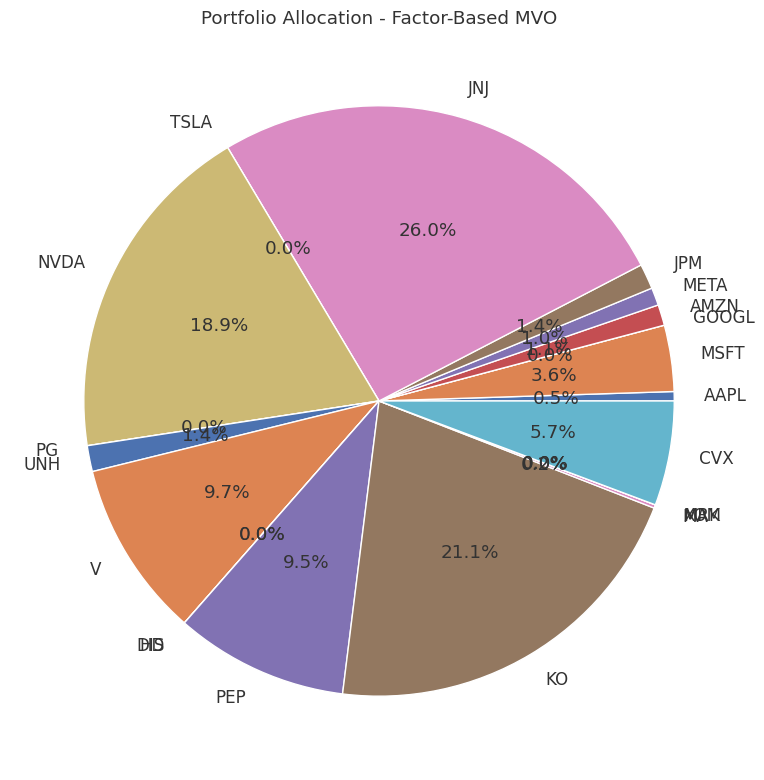

In [ ]:
# Factor-Based MVO Allocation Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(cleaned_factor_weights.values(), labels=cleaned_factor_weights.keys(), autopct='%1.1f%%')
plt.title("Portfolio Allocation - Factor-Based MVO")
plt.tight_layout()
plt.show()


In [ ]:
from pypfopt import plotting

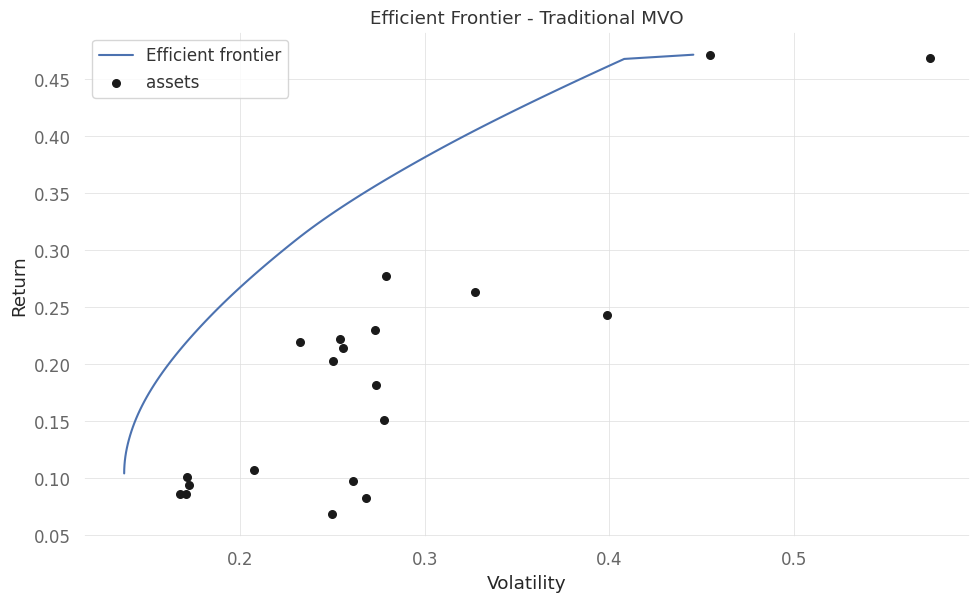

In [ ]:
# Plot of Efficient Frontier for Traditional MVO
ef_plot = EfficientFrontier(mu, S,solver="ECOS")
fig, ax = plt.subplots(figsize=(10,6))
plotting.plot_efficient_frontier(ef_plot, ax=ax, show_assets=True)
plt.title("Efficient Frontier - Traditional MVO")
plt.xlabel("Volatility")
plt.ylabel("Return")
plt.grid(True)
plt.show()

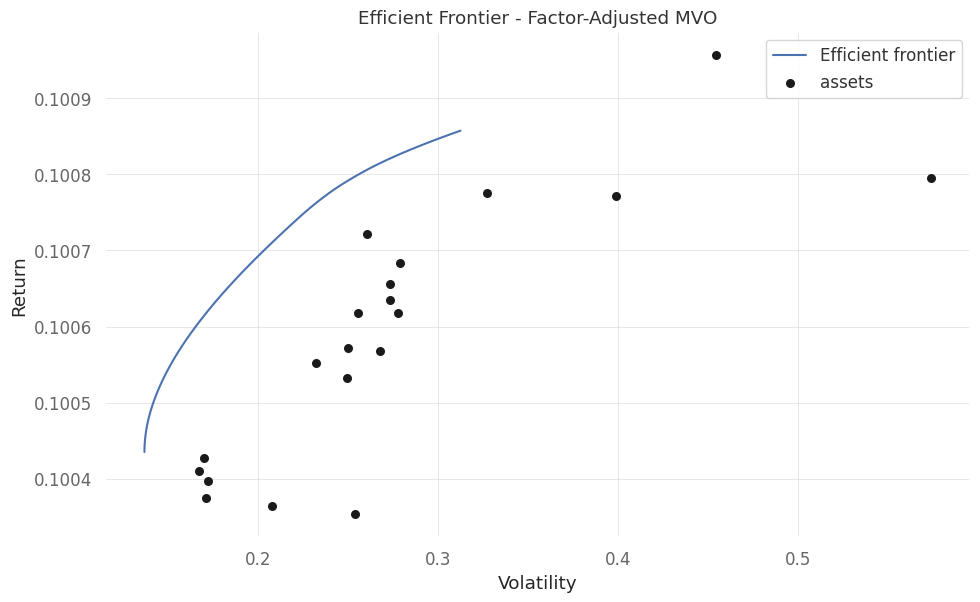

In [ ]:
# Plot of Efficient Frontier for Factor-Adjusted MVO
ef_plot_1 = EfficientFrontier(mu_factor, S, solver="ECOS")  # or solver="SCS"
fig, ax = plt.subplots(figsize=(10, 6))
plotting.plot_efficient_frontier(ef_plot_1, ax=ax, show_assets=True)
plt.title("Efficient Frontier - Factor-Adjusted MVO")
plt.xlabel("Volatility")
plt.ylabel("Return")
plt.grid(True)
plt.show()


comparing both

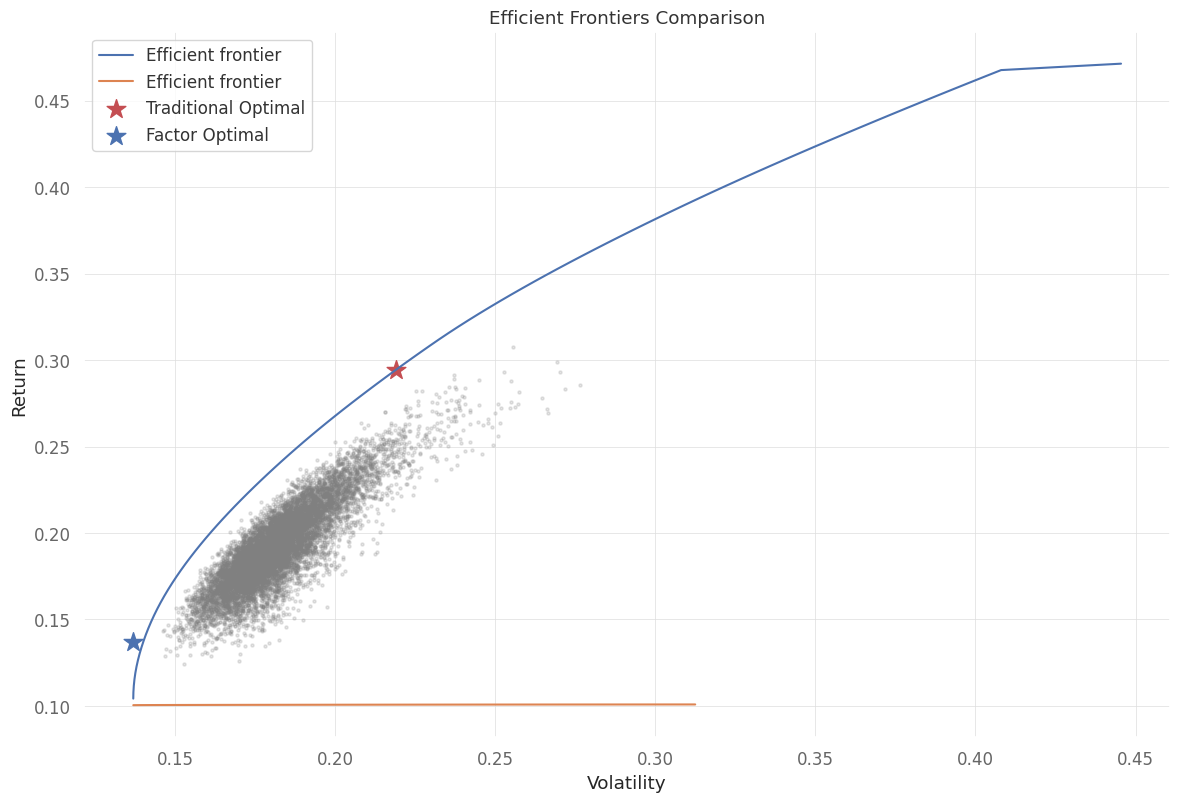

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))

# Traditional MVO
ef_trad = EfficientFrontier(mu, S,solver="ECOS")
plotting.plot_efficient_frontier(ef_trad, ax=ax, show_assets=False, label="Traditional MVO")

# Factor-Adjusted MVO
ef_factor = EfficientFrontier(mu_factor, S, solver="ECOS")
plotting.plot_efficient_frontier(ef_factor, ax=ax, show_assets=False, label="Factor-Adjusted MVO")

# Traditional Optimal
ef_opt_trad = EfficientFrontier(mu, S)
w_trad = ef_opt_trad.max_sharpe()
ret_trad, vol_trad, _ = ef_opt_trad.portfolio_performance()
ax.scatter(vol_trad, ret_trad, marker='*', s=200, c='r', label="Traditional Optimal")

# Factor-Adjusted Optima
ef_opt_factor = EfficientFrontier(mu_factor, S)
w_factor = ef_opt_factor.max_sharpe()
ret_factor, vol_factor, _ = ef_opt_factor.portfolio_performance()
ax.scatter(vol_factor, vol_factor, marker='*', s=200, c='b', label="Factor Optimal")

n_samples = 10000
w = np.random.dirichlet(np.ones(len(mu)), n_samples)
rets = w.dot(mu)
stds = np.sqrt(np.diag(w.dot(S).dot(w.T)))
ax.scatter(stds, rets, s=5, alpha=0.2, c='gray')

plt.title("Efficient Frontiers Comparison")
plt.xlabel("Volatility")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.show()